# Exploring Global Life Expectancy Trends with LLM‑Assisted Analytics

*A hands‑on tutorial for actuaries working in global life‑insurance risk management*

### Learning goals
1. **Use a large‑language‑model coding assistant** (e.g. GitHub Copilot, Cursor, or JetBrains AI Assistant) inside JupyterLab/VS Code to speed up exploratory data analysis (EDA).
2. **Load and interrogate an open mortality dataset** (UN World Population Prospects 2024 life‑expectancy series, via *Our World in Data*).
3. **Derive actuarial insights**: life‑expectancy improvements, stress testing, and simple stochastic projections.
4. **Create publication‑quality visuals** to share with non‑actuarial stakeholders.
5. **Discuss next steps** for integrating LLMs into pricing and risk‑capital workflows.


> **Tip 💡**  
> If you are running this notebook in VS Code with GitHub Copilot, start your code cell with a descriptive comment such as `# Plot life‑expectancy improvements for select regions` and press <kbd>⌥</kbd>+<kbd>↩︎</kbd> (Mac) or <kbd>Alt</kbd>+<kbd>Enter</kbd> (Win) to let Copilot suggest the full snippet.

---
Run the cell below to import common scientific‑stack libraries. Install any that are missing (on Binder they’re pre‑installed).

In [1]:
# If you get import errors, run the following line once:
# %pip install pandas matplotlib seaborn plotly statsmodels scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### 1 ▸ Load UN WPP life‑expectancy data

The CSV is hosted by *Our World in Data* and covers **1950 – 2023**. Each row is `(entity, code, year, life_expectancy)` expressed in _years at birth_.


In [10]:
url = "life-expectancy-unwpp.csv"  # public, no API‑key needed
le = pd.read_csv(url)
le.head()

,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,28.156
1,Afghanistan,AFG,1951,28.584
2,Afghanistan,AFG,1952,29.014
3,Afghanistan,AFG,1953,29.452
4,Afghanistan,AFG,1954,29.698


### 2 ▸ Basic data hygiene

In [11]:
# Get a list of all countries
le['Code'].unique()

array(['AFG', nan, 'ALB', 'DZA', 'ASM', 'AND', 'AGO', 'AIA', 'ATG', 'ARG',
       'ARM', 'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB',
       'BLR', 'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL', 'BES', 'BIH',
       'BWA', 'BRA', 'VGB', 'BRN', 'BGR', 'BFA', 'BDI', 'KHM', 'CMR',
       'CAN', 'CPV', 'CYM', 'CAF', 'TCD', 'CHL', 'CHN', 'COL', 'COM',
       'COG', 'COK', 'CRI', 'CIV', 'HRV', 'CUB', 'CUW', 'CYP', 'CZE',
       'COD', 'DNK', 'DJI', 'DMA', 'DOM', 'TLS', 'ECU', 'EGY', 'SLV',
       'GNQ', 'ERI', 'EST', 'SWZ', 'ETH', 'FLK', 'FRO', 'FJI', 'FIN',
       'FRA', 'GUF', 'PYF', 'GAB', 'GMB', 'GEO', 'DEU', 'GHA', 'GIB',
       'GRC', 'GRL', 'GRD', 'GLP', 'GUM', 'GTM', 'GGY', 'GIN', 'GNB',
       'GUY', 'HTI', 'HND', 'HKG', 'HUN', 'ISL', 'IND', 'IDN', 'IRN',
       'IRQ', 'IRL', 'IMN', 'ISR', 'ITA', 'JAM', 'JPN', 'JEY', 'JOR',
       'KAZ', 'KEN', 'KIR', 'OWID_KOS', 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN',
       'LSO', 'LBR', 'LBY', 'LIE', 'LTU', 'LUX', 'MAC', 'MDG', 'MWI',
       'MY

In [14]:
# Keep only countries (drop OWID aggregates)
le_c = le[le['Code'].str.len() == 3].copy()
# Check missing values
le_c.isna().sum()

Entity             0
Code               0
Year               0
Life expectancy    0
dtype: int64

### 3 ▸ Exploratory analysis

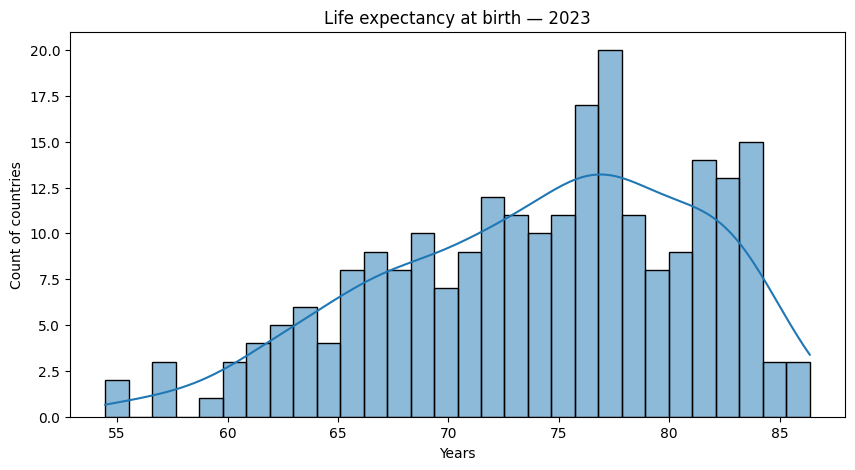

In [15]:
latest_year = le_c['Year'].max()
world_2023 = le_c[le_c['Year'] == latest_year]
plt.figure(figsize=(10,5))
sns.histplot(world_2023['Life expectancy'], bins=30, kde=True)
plt.title(f'Life expectancy at birth — {latest_year}')
plt.xlabel('Years')
plt.ylabel('Count of countries')
plt.show()

### 4 ▸ Mortality improvement metrics

In [19]:
# Compute YoY improvement (%) by entity
def calc_impr(df):
    df = df.sort_values('Year')
    df['improvement_pct'] = df['Life expectancy'].pct_change()*100
    return df

le_imp = le_c.groupby('Entity', group_keys=False).apply(calc_impr)
le_imp.head()

/var/folders/qz/2gvb8hqn4vq7m0n3kflldxnw0000gn/T/ipykernel_905/1330524929.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  le_imp = le_c.groupby('Entity', group_keys=False).apply(calc_impr)


,Entity,Code,Year,Life expectancy,improvement_pct
0,Afghanistan,AFG,1950,28.156,NaN
1,Afghanistan,AFG,1951,28.584,1.520102
2,Afghanistan,AFG,1952,29.014,1.504338
3,Afghanistan,AFG,1953,29.452,1.509616
4,Afghanistan,AFG,1954,29.698,0.835257


---
> **LLM prompt idea 🧑‍💻**  
> *“Write a function that ranks countries by the average annual life‑expectancy improvement over the last 20 years and plot the top 10.”*

In [ ]:
# write the code here

### 5 ▸ Quick stochastic projection (Lee‑Carter placeholder)

In [ ]:
# TODO: Ask Copilot/Cursor to generate Lee‑Carter or ARIMA code here


### 6 ▸ Capital stress example
*Quantify the impact of a ‑1.5‑year shock to life expectancy on best‑estimate liabilities (BEL). Placeholder code below assumes a flat **−2 %** increase in q‑rates across all ages.*

In [21]:
# Placeholder: imagine liabilities vector and apply shock
BEL_base = 1e9  # mock BEL in USD
shock_factor = 1.02  # increase in mortality rates
BEL_stressed = BEL_base * shock_factor
print(f"BEL base:     {BEL_base:,.0f}\nBEL stressed: {BEL_stressed:,.0f}")

BEL base:     1,000,000,000
BEL stressed: 1,020,000,000


## Next steps
* Connect to internal experience data and calibrate mortality improvements.
* Extend to multi‑scenario ESG capital projections.
* Embed these notebook workflows inside your model governance framework (e.g. Model Risk tiering & peer review checkpoints).

---
© 2025 Marc Fiani — Licensed under CC‑BY‑SA 4.0
